# Forecasting Model Development

This notebook develops and evaluates forecasting models using the engineered ILINet dataset. The workflow focuses on predicting weekly influenza-like illness activity from historical and temporal features.

#### 1. Import Libraries

In [1]:
# Import libraries
import warnings

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.ensemble import RandomForestRegressor
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

from src.data_loader import PROJECT_ROOT, PROCESSED_DATA

# Output directory for figures
figures_dir = PROJECT_ROOT / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore")

#### 2. Display Settings

In [2]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)
pd.set_option("display.width", 120)

#### 3. Load the engineered dataset

In [3]:
# Load engineered dataset
df = pd.read_csv(
    PROCESSED_DATA / "ILINet_engineered.csv",
    parse_dates=["DATE"]
)

#### 4. Dataset Overview

In [4]:
# Display dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1499 entries, 0 to 1498
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   REGION TYPE                   1499 non-null   str           
 1   DATE                          1499 non-null   datetime64[us]
 2   YEAR                          1499 non-null   int64         
 3   WEEK                          1499 non-null   int64         
 4   % WEIGHTED ILI                1499 non-null   float64       
 5   %UNWEIGHTED ILI               1499 non-null   float64       
 6   AGE 0-4                       1499 non-null   int64         
 7   AGE 25-49                     967 non-null    float64       
 8   AGE 25-64                     627 non-null    float64       
 9   AGE 5-24                      1499 non-null   int64         
 10  AGE 50-64                     967 non-null    float64       
 11  AGE 65                        1499 non-nu

#### 5. Forecasting Target

In [5]:
# Define forecasting target
target = "% WEIGHTED ILI"

In [6]:
# Display target summary
df[target].describe()

count    1499.000000
mean        1.931710
std         1.489125
min         0.000000
25%         0.987856
50%         1.501950
75%         2.409965
max         8.280040
Name: % WEIGHTED ILI, dtype: float64

In [7]:
# Define model features
features = [
    "WEEK",
    "month",
    "quarter",
    "week_sin",
    "week_cos",
    "weighted_ili_lag_1",
    "weighted_ili_lag_2",
    "weighted_ili_lag_4",
    "weighted_ili_lag_52",
    "weighted_ili_rolling_mean_4",
    "weighted_ili_rolling_mean_12",
    "weighted_ili_rolling_std_4"
]

In [8]:
# Create feature matrix and target
X = df[features]
y = df[target]

In [9]:
# Display feature matrix shape
X.shape

(1499, 12)

#### 6. Time-Series Train/Test Split

In [10]:
# Define time-series train/test split
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [11]:
# Check train and test sizes
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (1199, 12)
Test set: (300, 12)


In [12]:
# Check train/test date ranges
print("Training period:", df["DATE"].iloc[:split_index].min(), "to", df["DATE"].iloc[:split_index].max())
print("Test period:", df["DATE"].iloc[split_index:].min(), "to", df["DATE"].iloc[split_index:].max())

Training period: 1997-09-28 00:00:00 to 2020-09-13 00:00:00
Test period: 2020-09-20 00:00:00 to 2026-06-14 00:00:00


In [13]:
# Check missing values in training features
X_train.isna().sum()

WEEK                             0
month                            0
quarter                          0
week_sin                         0
week_cos                         0
weighted_ili_lag_1               1
weighted_ili_lag_2               2
weighted_ili_lag_4               4
weighted_ili_lag_52             52
weighted_ili_rolling_mean_4      4
weighted_ili_rolling_mean_12    12
weighted_ili_rolling_std_4       4
dtype: int64

In [14]:
# Remove rows with incomplete model features
train_mask = X_train.notna().all(axis=1)

X_train = X_train.loc[train_mask]
y_train = y_train.loc[train_mask]

print("Training set:", X_train.shape)
print("Missing values:", X_train.isna().sum().sum())

Training set: (1147, 12)
Missing values: 0


In [15]:
# Check missing values in test features
X_test.isna().sum()

WEEK                            0
month                           0
quarter                         0
week_sin                        0
week_cos                        0
weighted_ili_lag_1              0
weighted_ili_lag_2              0
weighted_ili_lag_4              0
weighted_ili_lag_52             0
weighted_ili_rolling_mean_4     0
weighted_ili_rolling_mean_12    0
weighted_ili_rolling_std_4      0
dtype: int64

### Seasonal Naive Baseline

The seasonal naive method provides a simple forecasting benchmark. Each week's influenza-like illness activity is predicted using the value observed approximately one year earlier, corresponding to a 52-week seasonal lag.

This baseline does not estimate model parameters. Instead, it provides a reference point for determining whether more sophisticated forecasting models provide meaningful improvements.

In [16]:
# Create seasonal naive baseline
y_pred_baseline = X_test["weighted_ili_lag_52"]

print(y_pred_baseline.head())

1199    1.33771
1200    1.49064
1201    1.59269
1202    1.72517
1203    1.83428
Name: weighted_ili_lag_52, dtype: float64


In [17]:
# Evaluate seasonal naive baseline
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)
baseline_rmse = mean_squared_error(y_test, y_pred_baseline) ** 0.5

print("Seasonal Naive Baseline")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)

Seasonal Naive Baseline
MAE: 1.0322971633333333
RMSE: 1.5871359512106549


### SARIMA Forecasting Model

SARIMA (Seasonal Autoregressive Integrated Moving Average) is a classical statistical time-series forecasting model that extends ARIMA by incorporating seasonal patterns.

The model is specified using non-seasonal parameters `(p, d, q)` and seasonal parameters `(P, D, Q, s)`, where:

- `p` controls the non-seasonal autoregressive component.
- `d` controls non-seasonal differencing.
- `q` controls the non-seasonal moving-average component.
- `P` controls the seasonal autoregressive component.
- `D` controls seasonal differencing.
- `Q` controls the seasonal moving-average component.
- `s` represents the seasonal period.

For this weekly influenza dataset, a seasonal period of 52 weeks is used to represent approximately annual seasonality.

The initial SARIMA specification used in this analysis is `SARIMA(1,0,1)(1,1,1,52)`. The model is trained on the historical training period and evaluated on the same held-out test period used for all other forecasting models.

In [18]:
# Prepare target series for SARIMA
ts = df[["DATE", target]].copy()

ts = ts.set_index("DATE")

sarima_train = ts.iloc[:split_index][target]
sarima_test = ts.iloc[split_index:][target]

print("SARIMA training period:", sarima_train.index.min(), "to", sarima_train.index.max())
print("SARIMA test period:", sarima_test.index.min(), "to", sarima_test.index.max())

print("Training observations:", len(sarima_train))
print("Test observations:", len(sarima_test))

SARIMA training period: 1997-09-28 00:00:00 to 2020-09-13 00:00:00
SARIMA test period: 2020-09-20 00:00:00 to 2026-06-14 00:00:00
Training observations: 1199
Test observations: 300


In [19]:
# Fit SARIMA model
sarima_model = SARIMAX(
    sarima_train,
    order=(1, 0, 1),
    seasonal_order=(1, 1, 1, 52),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(disp=False)

print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                     % WEIGHTED ILI   No. Observations:                 1199
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 52)   Log Likelihood                -322.050
Date:                            Fri, 02 Oct 2026   AIC                            654.100
Time:                                    10:09:14   BIC                            679.083
Sample:                                09-28-1997   HQIC                           663.554
                                     - 09-13-2020                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9058      0.007    130.399      0.000       0.892       0.919
ma.L1          0.3463      0.016   

In [20]:
# Generate SARIMA forecasts
sarima_forecast = sarima_result.forecast(steps=len(sarima_test))

print(sarima_forecast.head())
print("Forecast observations:", len(sarima_forecast))

2020-09-20    1.011688
2020-09-27    1.167344
2020-10-04    1.228990
2020-10-11    1.327281
2020-10-18    1.476913
Freq: W-SUN, Name: predicted_mean, dtype: float64
Forecast observations: 300


In [21]:
# Evaluate SARIMA forecast
sarima_mae = mean_absolute_error(sarima_test, sarima_forecast)
sarima_rmse = mean_squared_error(sarima_test, sarima_forecast) ** 0.5

print("SARIMA")
print("MAE:", sarima_mae)
print("RMSE:", sarima_rmse)

print("\nSeasonal Naive Baseline")
print("MAE:", baseline_mae)
print("RMSE:", baseline_rmse)

SARIMA
MAE: 1.02267411943667
RMSE: 1.4484935152472787

Seasonal Naive Baseline
MAE: 1.0322971633333333
RMSE: 1.5871359512106549


### SARIMA Diagnostics

Before testing additional forecasting models, the SARIMA model is examined using stationarity and autocorrelation diagnostics. These diagnostics help assess the time-series structure and provide guidance for potential SARIMA parameter refinement.

In [22]:
# Augmented Dickey-Fuller test
adf_result = adfuller(sarima_train)

print("ADF statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Critical values:")

for key, value in adf_result[4].items():
    print(f"  {key}: {value}")

ADF statistic: -9.603226238209851
p-value: 1.8959756307377846e-16
Critical values:
  1%: -3.435913333460925
  5%: -2.863996640985854
  10%: -2.5680779665111078


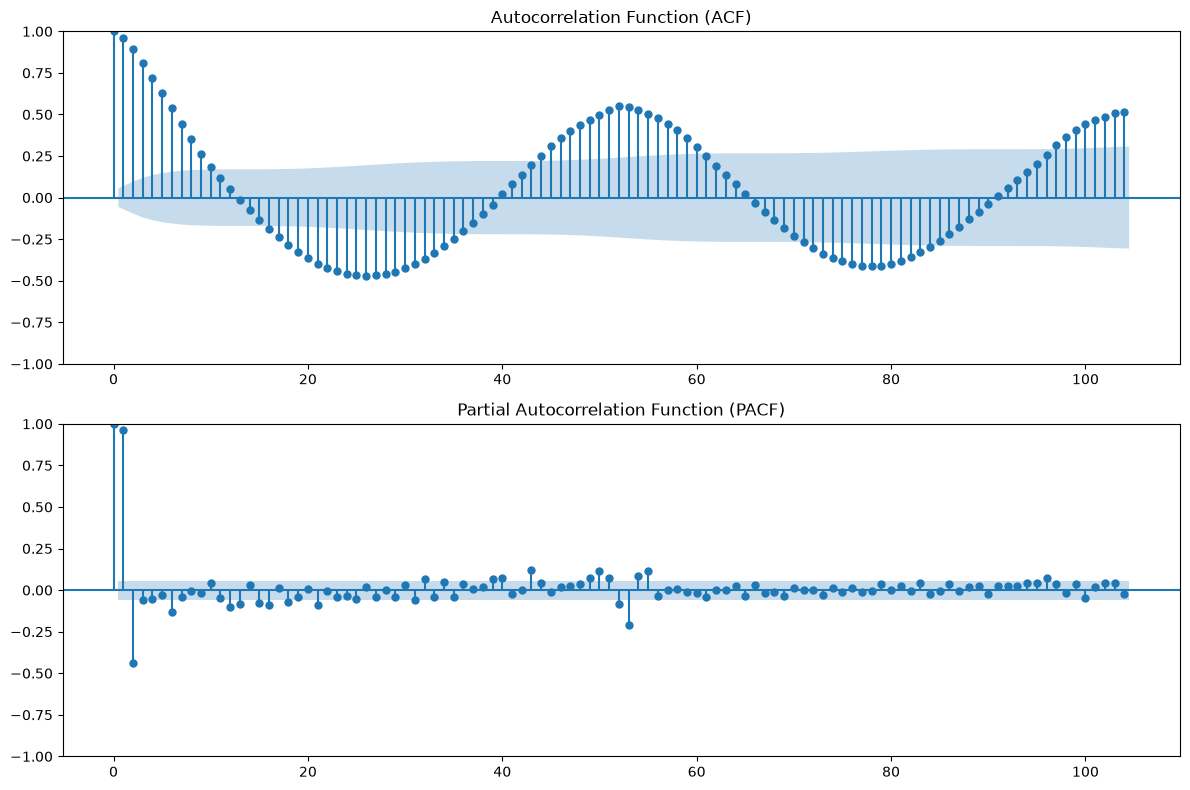

In [23]:
# Plot ACF and PACF
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(sarima_train, lags=104, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(sarima_train, lags=104, ax=axes[1], method="ywm")
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.tight_layout()
plt.show()

### Prophet Forecasting Model

Prophet is a forecasting model designed for time-series data with trend and seasonal patterns. It represents the time series using components such as trend and seasonality.

For this analysis, Prophet is configured with yearly seasonality to capture recurring annual patterns in weekly influenza-like illness activity. Weekly and daily seasonality are disabled because the dataset contains weekly observations.

The model is trained on the same historical training period used for SARIMA and evaluated on the same held-out test period.

In [24]:
# Prepare training data for Prophet
prophet_train = sarima_train.reset_index()

prophet_train.columns = ["ds", "y"]

print(prophet_train.head())
print("Training observations:", len(prophet_train))

          ds        y
0 1997-09-28  1.10148
1 1997-10-05  1.20007
2 1997-10-12  1.37876
3 1997-10-19  1.19920
4 1997-10-26  1.65618
Training observations: 1199


In [25]:
# Initialize Prophet model
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

# Fit Prophet model
prophet_model.fit(prophet_train)

10:09:49 - cmdstanpy - INFO - Chain [1] start processing
10:09:52 - cmdstanpy - INFO - Chain [1] done processing


In [26]:
# Prepare test dates for Prophet
prophet_future = sarima_test.index.to_frame(index=False)
prophet_future.columns = ["ds"]

print(prophet_future.head())
print(prophet_future.tail())
print("Test observations:", len(prophet_future))

          ds
0 2020-09-20
1 2020-09-27
2 2020-10-04
3 2020-10-11
4 2020-10-18
            ds
295 2026-05-17
296 2026-05-24
297 2026-05-31
298 2026-06-07
299 2026-06-14
Test observations: 300


In [27]:
# Generate Prophet forecasts
prophet_forecast = prophet_model.predict(prophet_future)

prophet_predictions = prophet_forecast["yhat"]

print(prophet_predictions.head())
print("Forecast observations:", len(prophet_predictions))

0    1.708225
1    1.939347
2    2.208713
3    2.375094
4    2.416562
Name: yhat, dtype: float64
Forecast observations: 300


In [28]:
# Evaluate Prophet forecast
prophet_mae = mean_absolute_error(
    sarima_test,
    prophet_predictions
)

prophet_rmse = mean_squared_error(
    sarima_test,
    prophet_predictions
) ** 0.5

print("Prophet")
print("MAE:", prophet_mae)
print("RMSE:", prophet_rmse)

Prophet
MAE: 0.8659226528046369
RMSE: 1.237161902522709


In [29]:
# Compare current forecasting models
comparison = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "SARIMA",
        "Prophet"
    ],
    "MAE": [
        baseline_mae,
        sarima_mae,
        prophet_mae
    ],
    "RMSE": [
        baseline_rmse,
        sarima_rmse,
        prophet_rmse
    ]
})

comparison

,Model,MAE,RMSE
0,Seasonal Naive,1.032297,1.587136
1,SARIMA,1.022674,1.448494
2,Prophet,0.865923,1.237162


### XGBoost Forecasting Model

XGBoost (Extreme Gradient Boosting) is a tree-based machine-learning algorithm that builds an ensemble of decision trees sequentially, with each new tree focusing on errors made by previous trees.

Unlike SARIMA and Prophet, XGBoost does not model the time series directly. Instead, forecasting is treated as a supervised learning problem using temporal and historical features such as week, cyclical week features, lagged ILI values, and rolling statistics.

The model is trained using the same chronological training period and evaluated on the same held-out test period as the other forecasting approaches.

In [30]:
# Initialize XGBoost model
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42
)

# Fit XGBoost model
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [31]:
# Generate XGBoost predictions
xgb_predictions = xgb_model.predict(X_test)

print("Forecast observations:", len(xgb_predictions))
print(xgb_predictions[:5])

Forecast observations: 300
[0.99155855 1.0422288  1.122757   1.2439318  1.1851298 ]


In [32]:
# Evaluate XGBoost forecast
xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = mean_squared_error(
    y_test,
    xgb_predictions
) ** 0.5

print("XGBoost")
print("MAE:", xgb_mae)
print("RMSE:", xgb_rmse)

XGBoost
MAE: 0.2005216163495636
RMSE: 0.314195358079787


In [33]:
# Updated model comparison
comparison = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "SARIMA",
        "Prophet",
        "XGBoost"
    ],
    "MAE": [
        baseline_mae,
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],
    "RMSE": [
        baseline_rmse,
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ]
})

comparison

,Model,MAE,RMSE
0,Seasonal Naive,1.032297,1.587136
1,SARIMA,1.022674,1.448494
2,Prophet,0.865923,1.237162
3,XGBoost,0.200522,0.314195


### Random Forest Forecasting Model

Random Forest is an ensemble machine-learning algorithm that combines predictions from multiple decision trees.

For this forecasting task, Random Forest treats the problem as supervised regression. Historical ILI values, temporal features, lag features, and rolling statistics are used as predictors of weekly influenza-like illness activity.

The model is trained using the same chronological training period and evaluated on the same held-out test period as the other forecasting approaches.

In [34]:
# Initialize Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features=1.0,
    random_state=42,
    n_jobs=-1
)

# Fit Random Forest model
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",500
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [35]:
# Generate Random Forest predictions
rf_predictions = rf_model.predict(X_test)

print("Forecast observations:", len(rf_predictions))
print(rf_predictions[:5])

Forecast observations: 300
[1.02157304 1.10635504 1.1546656  1.2731888  1.1848401 ]


In [36]:
# Evaluate Random Forest forecast
rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_rmse = mean_squared_error(
    y_test,
    rf_predictions
) ** 0.5

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)

Random Forest
MAE: 0.17904156263333376
RMSE: 0.27770355536836266


### Actual vs Predicted Values

The forecasting models are compared visually by plotting their predictions against the observed `% WEIGHTED ILI` values in the held-out test period. This allows differences in forecast accuracy, seasonal patterns, peaks, and periods of larger prediction errors to be examined alongside the numerical evaluation metrics.

In [37]:
# Combine actual and predicted values
forecast_comparison = pd.DataFrame({
    "DATE": sarima_test.index,
    "Actual": y_test.values,
    "Seasonal Naive": y_pred_baseline.values,
    "SARIMA": sarima_forecast.values,
    "Prophet": prophet_predictions.values,
    "XGBoost": xgb_predictions,
    "Random Forest": rf_predictions
})

forecast_comparison.head()

,DATE,Actual,Seasonal Naive,SARIMA,Prophet,XGBoost,Random Forest
0,2020-09-20,1.06462,1.33771,1.011688,1.708225,0.991559,1.021573
1,2020-09-27,1.09211,1.49064,1.167344,1.939347,1.042229,1.106355
2,2020-10-04,1.21201,1.59269,1.228990,2.208713,1.122757,1.154666
3,2020-10-11,1.11151,1.72517,1.327281,2.375094,1.243932,1.273189
4,2020-10-18,1.18662,1.83428,1.476913,2.416562,1.185130,1.184840


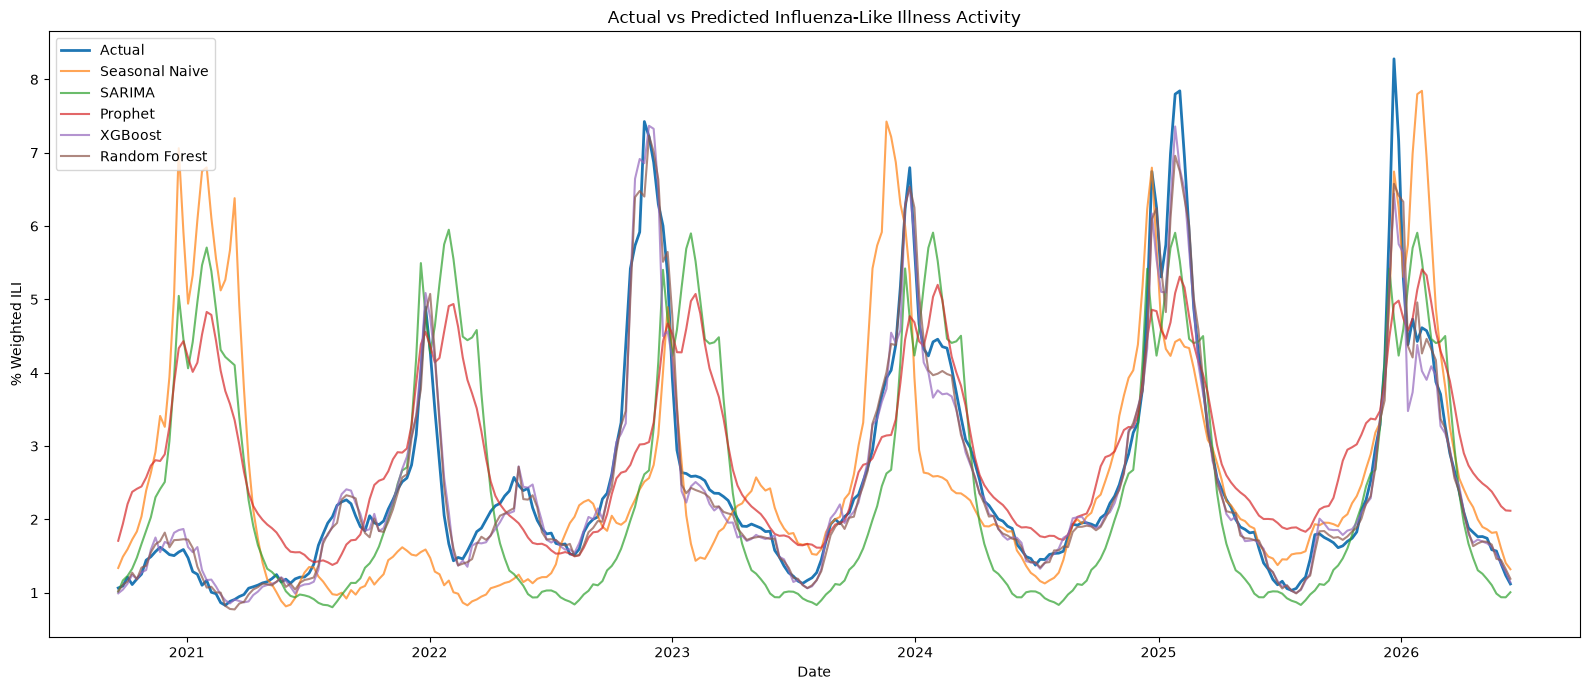

In [38]:
# Plot actual values vs predicted values
fig, ax = plt.subplots(figsize=(16, 7))

ax.plot(
    forecast_comparison["DATE"],
    forecast_comparison["Actual"],
    label="Actual",
    linewidth=2
)

ax.plot(
    forecast_comparison["DATE"],
    forecast_comparison["Seasonal Naive"],
    label="Seasonal Naive",
    alpha=0.7
)

ax.plot(
    forecast_comparison["DATE"],
    forecast_comparison["SARIMA"],
    label="SARIMA",
    alpha=0.7
)

ax.plot(
    forecast_comparison["DATE"],
    forecast_comparison["Prophet"],
    label="Prophet",
    alpha=0.7
)

ax.plot(
    forecast_comparison["DATE"],
    forecast_comparison["XGBoost"],
    label="XGBoost",
    alpha=0.7
)

ax.plot(
    forecast_comparison["DATE"],
    forecast_comparison["Random Forest"],
    label="Random Forest",
    alpha=0.7
)

ax.set_title("Actual vs Predicted Influenza-Like Illness Activity")
ax.set_xlabel("Date")
ax.set_ylabel("% Weighted ILI")
ax.legend()

plt.tight_layout()
fig.savefig(figures_dir / "actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

### Feature Importance

The tree-based forecasting models use the engineered temporal and historical features to predict weekly influenza-like illness activity. Feature importance is examined to identify which predictors contributed most strongly to the predictions made by the XGBoost and Random Forest models.

Feature importance provides an indication of how useful each feature was to the fitted model, but it should not be interpreted as evidence of causation.

In [39]:
# XGBoost feature importance
xgb_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    "Importance",
    ascending=False
)

xgb_importance

,Feature,Importance
5,weighted_ili_lag_1,0.724669
6,weighted_ili_lag_2,0.139556
3,week_sin,0.031040
8,weighted_ili_lag_52,0.019708
4,week_cos,0.015203
9,weighted_ili_rolling_mean_4,0.014634
0,WEEK,0.013530
10,weighted_ili_rolling_mean_12,0.012855
7,weighted_ili_lag_4,0.011107
2,quarter,0.006522


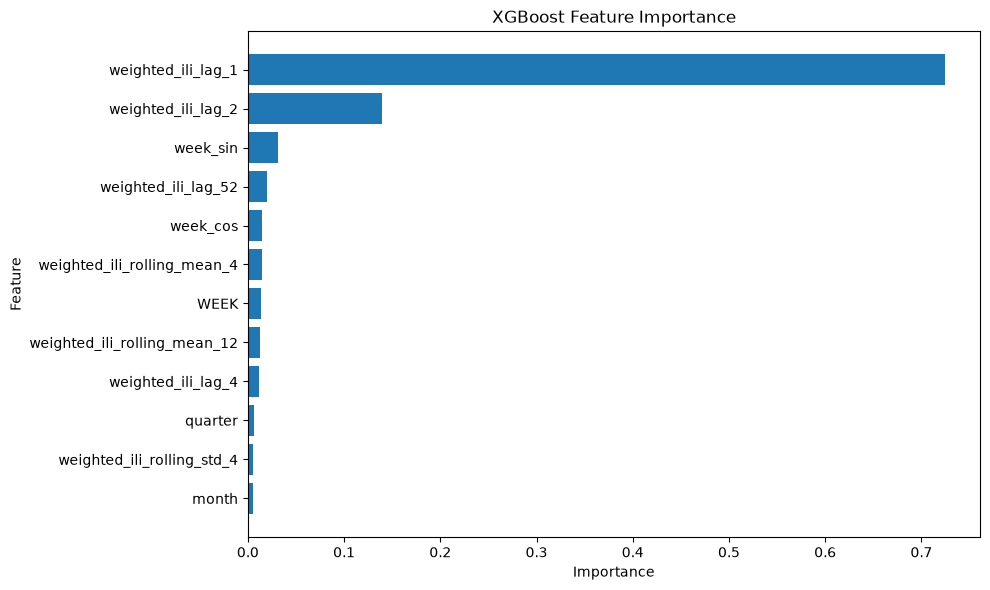

In [40]:
# Plot XGBoost feature importance
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    xgb_importance["Feature"],
    xgb_importance["Importance"]
)

ax.invert_yaxis()

ax.set_title("XGBoost Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
fig.savefig(figures_dir / "feature_importance_XGB.png", dpi=300, bbox_inches="tight")
plt.show()

In [41]:
# Random Forest feature importance
rf_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    "Importance",
    ascending=False
)

rf_importance

,Feature,Importance
5,weighted_ili_lag_1,0.921396
8,weighted_ili_lag_52,0.026682
0,WEEK,0.009323
10,weighted_ili_rolling_mean_12,0.008960
6,weighted_ili_lag_2,0.007586
3,week_sin,0.007371
7,weighted_ili_lag_4,0.005177
4,week_cos,0.004476
11,weighted_ili_rolling_std_4,0.004309
9,weighted_ili_rolling_mean_4,0.003353


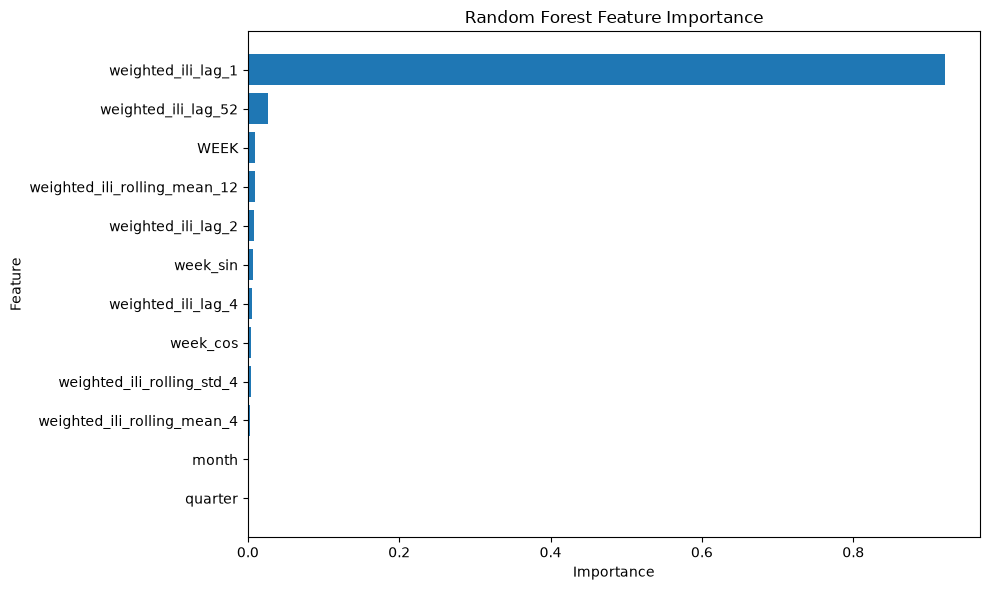

In [42]:
# Plot Random Forest feature importance
fig, ax = plt.subplots(figsize=(10, 6))

ax.barh(
    rf_importance["Feature"],
    rf_importance["Importance"]
)

ax.invert_yaxis()

ax.set_title("Random Forest Feature Importance")
ax.set_xlabel("Importance")
ax.set_ylabel("Feature")

plt.tight_layout()
fig.savefig(figures_dir / "feature_importance_RF.png", dpi=300, bbox_inches="tight")
plt.show()

### Final Model Comparison

The forecasting models are compared using Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE) on the held-out test period. Both metrics measure forecast error, with lower values indicating smaller prediction errors.

In [43]:
# Create final model comparison table
comparison = pd.DataFrame({
    "Model": [
        "Seasonal Naive",
        "SARIMA",
        "Prophet",
        "XGBoost",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        sarima_mae,
        prophet_mae,
        xgb_mae,
        rf_mae
    ],
    "RMSE": [
        baseline_rmse,
        sarima_rmse,
        prophet_rmse,
        xgb_rmse,
        rf_rmse
    ]
})

comparison

,Model,MAE,RMSE
0,Seasonal Naive,1.032297,1.587136
1,SARIMA,1.022674,1.448494
2,Prophet,0.865923,1.237162
3,XGBoost,0.200522,0.314195
4,Random Forest,0.179042,0.277704


### Model Error Comparison

The following visualizations compare the forecasting models based on their MAE and RMSE values.

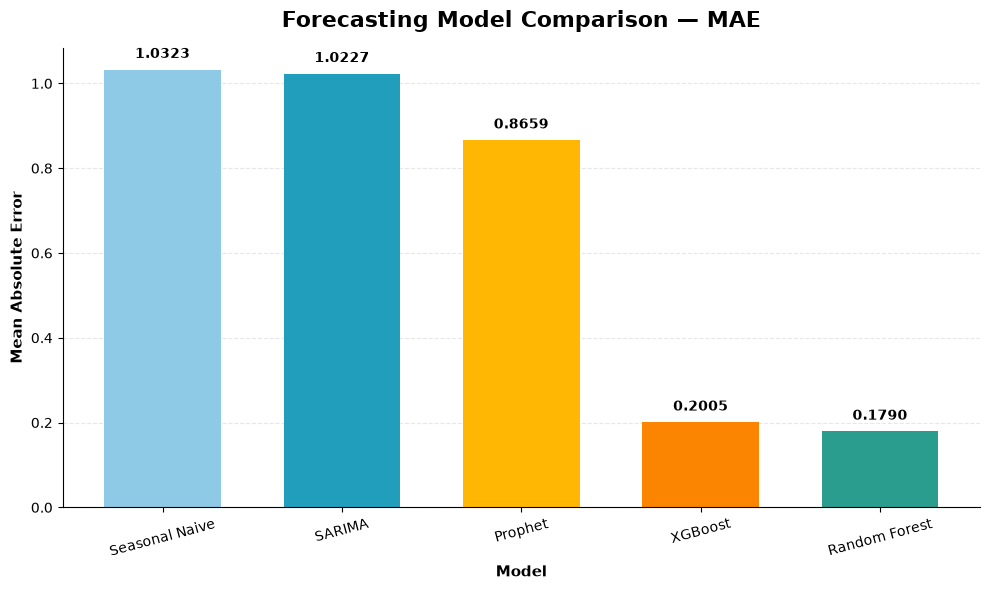

In [44]:
# Plot final MAE comparison
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(
    comparison["Model"],
    comparison["MAE"],
    color=[
        "#8ECAE6",
        "#219EBC",
        "#FFB703",
        "#FB8500",
        "#2A9D8F"
    ],
    width=0.65
)

ax.set_title("Forecasting Model Comparison — MAE", 
             fontsize=16, fontweight="bold", pad=15
             )

ax.set_xlabel("Model", 
              fontsize=11, fontweight="bold")

ax.set_ylabel("Mean Absolute Error", 
              fontsize=11, fontweight="bold")

ax.grid(axis="y", linestyle="--", alpha=0.3)

ax.set_axisbelow(True)

for bar, value in zip(bars, comparison["MAE"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.02,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig(figures_dir / "model_comparison_mae.png", dpi=300, bbox_inches="tight")
plt.show()

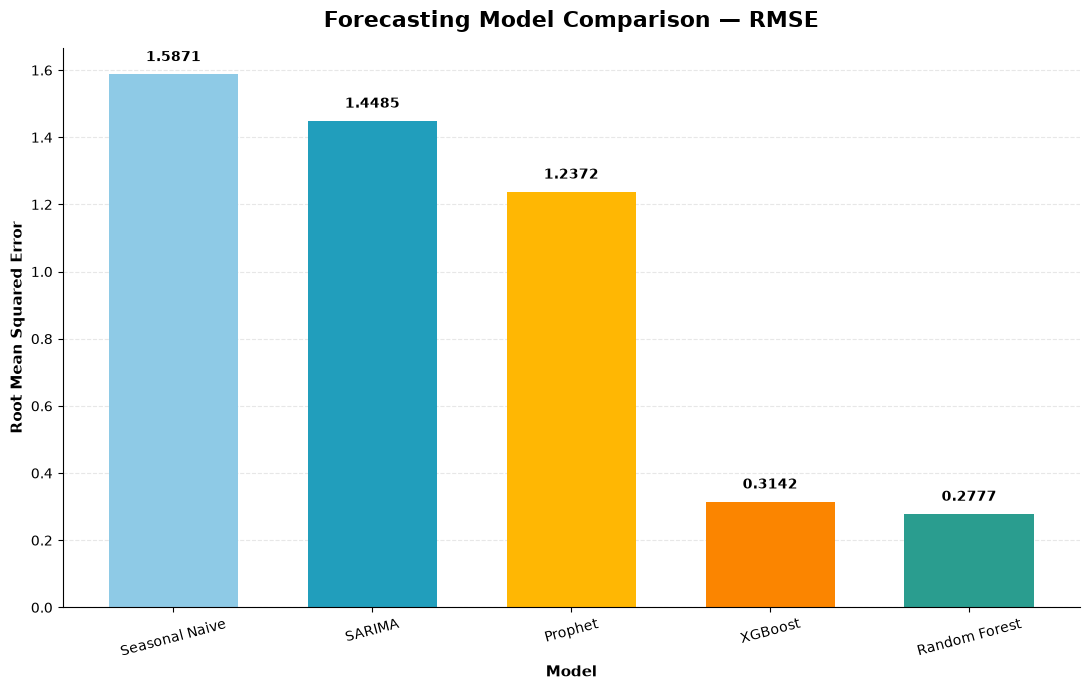

In [45]:
# Plot final RMSE comparison
fig, ax = plt.subplots(figsize=(11, 7))

bars = ax.bar(
    comparison["Model"],
    comparison["RMSE"],
    color=[
        "#8ECAE6",
        "#219EBC",
        "#FFB703",
        "#FB8500",
        "#2A9D8F"
    ],
    width=0.65
)

ax.set_title("Forecasting Model Comparison — RMSE", 
             fontsize=16, fontweight="bold", pad=15
             )

ax.set_xlabel("Model", 
              fontsize=11, fontweight="bold")

ax.set_ylabel("Root Mean Squared Error", 
              fontsize=11, fontweight="bold")

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

ax.set_axisbelow(True)

for bar, value in zip(bars, comparison["RMSE"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{value:.4f}",
        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.xticks(rotation=15)
plt.tight_layout()
fig.savefig(figures_dir / "model_comparison_rmse.png", dpi=300, bbox_inches="tight")
plt.show()

### Saving Final Outputs

In [47]:
# Output directories
output_dir = PROJECT_ROOT / "outputs"
forecast_dir = output_dir / "forecasts"

forecast_dir.mkdir(parents=True, exist_ok=True)

# Save forecast results
forecast_comparison.to_csv(
    forecast_dir / "forecast_comparison.csv",
    index=False
)

# Save model comparison
comparison.to_csv(
    forecast_dir / "model_comparison.csv",
    index=False
)

## Modeling Summary

Five forecasting approaches were evaluated using the same chronological train-test split and held-out test period: a seasonal naive baseline, SARIMA, Prophet, XGBoost, and Random Forest.

The seasonal naive baseline provided a reference point based on the value observed approximately 52 weeks earlier. SARIMA and Prophet incorporated temporal and seasonal structure directly, while XGBoost and Random Forest treated forecasting as a supervised regression problem using engineered temporal, lag, and rolling features.

Among the evaluated models, the tree-based approaches produced substantially lower MAE and RMSE values on the held-out test period. Random Forest achieved an MAE of approximately 0.179 and RMSE of approximately 0.278, while XGBoost achieved an MAE of approximately 0.201 and RMSE of approximately 0.314.

The feature-importance analysis showed that `weighted_ili_lag_1` was the dominant predictor for both tree-based models, indicating that recent influenza-like illness activity provided substantial predictive information in this forecasting setup.

The results represent a rolling one-step-ahead forecasting scenario in which historical observations available before each prediction are used to construct the forecasting features. The model comparison therefore reflects predictive performance under this evaluation setup rather than a single long-horizon forecast.